# Model Setup and Loading

In [2]:
import sys

# Add project root in the path
sys.path.append('..')

In [3]:
from src.model_utils import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer('gpt2')

d:\Deep Learning - Github\logit-lens-vs-tuned-lens\logit-lens-vs-tuned-lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10568.77it/s]


# Baseline

In this section, we'll use the text “The sky is usually,” and we expect the model to predict “blue”. First, let's verify that the model we imported—in this case, GPT-2—actually makes this prediction.

In [4]:
prompt = 'The sky is usually'

In [5]:
import torch

# Tokenizer the input
inputs = tokenizer(prompt, return_tensors='pt')

with torch.no_grad():
    output = model(**inputs)
    
logits = output.logits
next_token_logits = logits[:, -1, :] # Take last token
next_token_id = torch.argmax(next_token_logits, dim=-1) # Most probably token

next_word = tokenizer.decode(next_token_id)

print(f'Next token prediction: {next_word}')

Next token prediction:  blue


# Logit Lens

Explicación del logit lens

In [17]:
from src.logit_lens import run_logit_lens

# Get prediction of all layers
layers_predictions = run_logit_lens(model, tokenizer, prompt, top_k=10)

# Get probability that the word is "blue"
probs = []

for i in range(1, 13):
    # Iterate in possible words
    for word, prob in layers_predictions[f'Layer {i}']:
        if word == ' blue': probs.append(prob)
        
    if len(probs) != i: probs.append(0.0) # If the word don't exist in the preds, prob = 0

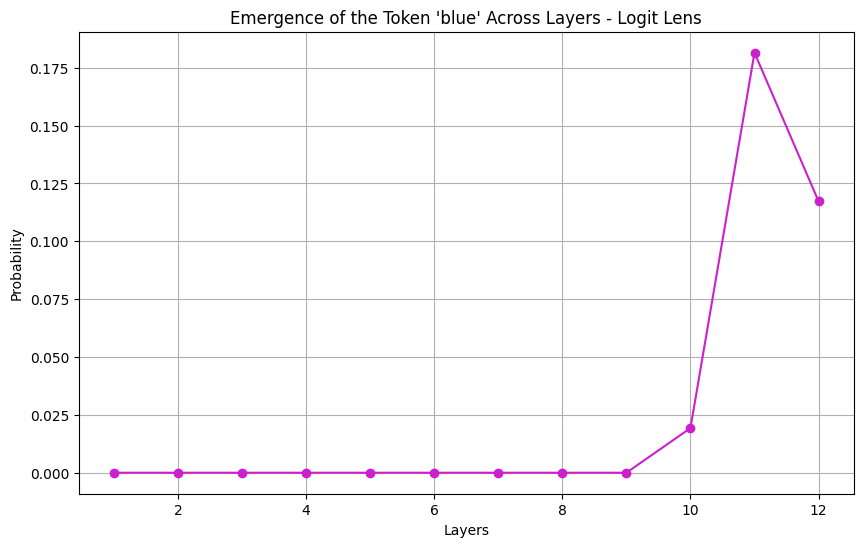

In [25]:
import matplotlib.pyplot as plt

#   
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(probs) + 1), probs, marker='o', color="#cc20cc")

plt.title('Emergence of the Token \'blue\' Across Layers - Logit Lens')
plt.xlabel('Layers')
plt.ylabel('Probability')

plt.grid()
plt.show()


Explicación del gráfico

# Tuned Lens

Explicación del tuned lens

# Visual Comparation